# *HUPA-UC DIABETES DATASET*

1. Project Title
2. Dataset Description
3. Data Cleaning
4. Missing Value Handling
5. Outlier Detection
6. Descriptive Statistics
7. Visualizations
8. Conclusion

# *COMPLETE DATA CLEANING CODE FOR DIABETES DATASET*

## STEP 1: IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## STEP 2: LOAD DATASET
The dataset was loaded using pandas.

**Reason for This Step**

The dataset must first be imported into Python so that it can be inspected, cleaned, analyzed, and visualized. Loading the data allows us to understand the structure, number of records, column names, and data types present in the dataset.

**How This Helps Analysis**

Loading the dataset correctly ensures that all records are accessible for statistical analysis, visualization, and machine learning tasks.

**Effect If This Step Is Not Done**

Without loading the dataset properly, no further analysis or preprocessing can be performed.

## COMBINE ALL FILES INTO ONE FILE

In [ ]:
import pandas as pd
import glob
files = glob.glob("HUPA-UC Diabetes Dataset/*.csv")
all_data = []
for file in files:
    df = pd.read_csv(file, sep=';')
    all_data.append(df)

In [ ]:
# Combine all files
combined_data = pd.concat(all_data, ignore_index=True)


In [ ]:
# Save final file
combined_data.to_csv("final_dataset.csv", index=False)

In [ ]:
print("All files combined successfully!")
print(combined_data.head())


## USING COMBINED FILE 

In [13]:
# Replace with your file name
import os

df = pd.read_csv(r"C:\Users\amhum\Downloads\final_dataset.csv", 
                 low_memory=False
)

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309417 entries, 0 to 309416
Data columns (total 9 columns):
 #   Column                                                                                                  Non-Null Count   Dtype  
---  ------                                                                                                  --------------   -----  
 0   time                                                                                                    309392 non-null  object 
 1   glucose                                                                                                 309392 non-null  float64
 2   calories                                                                                                309392 non-null  float64
 3   heart_rate                                                                                              309392 non-null  float64
 4   steps                                                                            

## STEP 3: VIEW BASIC INFORMATION
**Reason for This Step**

The shape of the dataset shows the total number of rows and columns. This helps identify the size of the dataset and verifies whether all files were combined correctly.

**How This Helps Analysis**

Understanding dataset dimensions helps estimate data quality and ensures that rows were not accidentally lost during merging or cleaning.

**Effect If This Step Is Not Done**

The analysis may proceed with incomplete or incorrectly merged data, leading to inaccurate conclusions.

In [14]:
print("\nFIRST 5 ROWS")
print(df.head())


FIRST 5 ROWS
                  time  glucose  calories  heart_rate  steps  basal_rate  \
0  2018-06-13T18:40:00    332.0    6.3595   82.322835   34.0    0.091667   
1  2018-06-13T18:45:00    326.0    7.7280   83.740157    0.0    0.091667   
2  2018-06-13T18:50:00    330.0    4.7495   80.525180    0.0    0.091667   
3  2018-06-13T18:55:00    324.0    6.3595   89.129032   20.0    0.091667   
4  2018-06-13T19:00:00    306.0    5.1520   92.495652    0.0    0.075000   

   bolus_volume_delivered  carb_input  \
0                     0.0         0.0   
1                     0.0         0.0   
2                     0.0         0.0   
3                     0.0         0.0   
4                     0.0         0.0   

  Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances  
0                                                NaN                                                      
1                                                NaN                

In [15]:
print("\nDATASET SHAPE")
print(df.shape)


DATASET SHAPE
(309417, 9)


In [16]:
print("\nCOLUMN NAMES")
print(df.columns)


COLUMN NAMES
Index(['time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate',
       'bolus_volume_delivered', 'carb_input',
       'Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances'],
      dtype='object')


In [17]:
print("\nDATA TYPES")
print(df.dtypes)


DATA TYPES
time                                                                                                       object
glucose                                                                                                   float64
calories                                                                                                  float64
heart_rate                                                                                                float64
steps                                                                                                     float64
basal_rate                                                                                                float64
bolus_volume_delivered                                                                                    float64
carb_input                                                                                                float64
Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10)

In [18]:
print("\nDATASET INFO")
print(df.info())


DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309417 entries, 0 to 309416
Data columns (total 9 columns):
 #   Column                                                                                                  Non-Null Count   Dtype  
---  ------                                                                                                  --------------   -----  
 0   time                                                                                                    309392 non-null  object 
 1   glucose                                                                                                 309392 non-null  float64
 2   calories                                                                                                309392 non-null  float64
 3   heart_rate                                                                                              309392 non-null  float64
 4   steps                                                              

# DATA CLEANING STARTS

## STEP 4: CLEAN COLUMN NAMES
**Reason for This Step**

Datasets often contain extra spaces, inconsistent capitalization, or special characters in column names. These inconsistencies can create problems while accessing columns in Python.

Example: 
" Glucose "  instead of:  Glucose

**How This Helps Analysis**

Standardized column names improve readability, reduce coding errors, and make analysis more efficient.

**Effect If This Step Is Not Done**

Incorrect column references may produce errors or prevent the analysis code from running properly.

In [20]:
# Removes extra spaces from column names

df.columns = df.columns.str.strip()

print("\nCLEANED COLUMN NAMES")
print(df.columns)


CLEANED COLUMN NAMES
Index(['time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate',
       'bolus_volume_delivered', 'carb_input',
       'Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances'],
      dtype='object')


## STEP 5: CHECK MISSING VALUES

**Reason for This Step**

Medical datasets commonly contain incomplete records due to missing patient information, skipped tests, or data collection errors.

**How This Helps Analysis**

Identifying missing values helps ensure that calculations such as averages, correlations, and predictions are based on complete and reliable information.

**Effect If This Step Is Not Done**

Missing values can:

distort statistical calculations
produce incorrect graphs
reduce machine learning accuracy
cause some algorithms to fail

In [21]:
print("\nMISSING VALUES")
print(df.isnull().sum())



MISSING VALUES
time                                                                                                          25
glucose                                                                                                       25
calories                                                                                                      25
heart_rate                                                                                                    25
steps                                                                                                         25
basal_rate                                                                                                    25
bolus_volume_delivered                                                                                        25
carb_input                                                                                                    25
Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% w

## STEP 6: HANDLE MISSING VALUES
Missing values were replaced using median values because medical datasets often contain outliers.

**Reason for This Step**

Missing data must be handled because many statistical and machine learning methods cannot process null values directly.

Median imputation was used for numeric columns because medical datasets often contain outliers, and the median is less affected by extreme values than the mean.

**How This Helps Analysis**

Replacing missing values preserves important records while maintaining a realistic distribution of the data.

**Effect If This Step Is Not Done**

The dataset may contain incomplete information, resulting in:

biased statistical results
inaccurate predictions
errors during analysis

In [22]:
# Fill numeric columns with median
# Fill text columns with mode

for column in df.columns:

    # Check if column is numeric
    if df[column].dtype in ['int64', 'float64']:

        # Replace missing numeric values with median
        df[column] = df[column].fillna(df[column].median())

    else:

        # Replace missing text values with mode
        df[column] = df[column].fillna(df[column].mode()[0])

print("\nMISSING VALUES AFTER CLEANING")
print(df.isnull().sum())



MISSING VALUES AFTER CLEANING
time                                                                                                      0
glucose                                                                                                   0
calories                                                                                                  0
heart_rate                                                                                                0
steps                                                                                                     0
basal_rate                                                                                                0
bolus_volume_delivered                                                                                    0
carb_input                                                                                                0
Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances   

## STEP 7: CHECK DUPLICATES
**Reason for This Step**

Duplicate records may occur when patient data is entered multiple times or when files are merged incorrectly.

**How This Helps Analysis**

Removing duplicates ensures that each patient or observation is counted only once, improving the reliability of statistics and machine learning models.

**Effect If This Step Is Not Done**

Duplicate records can:

bias averages and frequencies
overrepresent certain patients
produce misleading trends
cause overfitting in machine learning models

In [23]:
print("\nNUMBER OF DUPLICATE ROWS")
print(df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("\nDATASET SHAPE AFTER REMOVING DUPLICATES")
print(df.shape)



NUMBER OF DUPLICATE ROWS
0

DATASET SHAPE AFTER REMOVING DUPLICATES
(309417, 9)


## STEP 8: FIX DATA TYPES
**Reason for This Step**

Some numerical columns may be incorrectly stored as text due to formatting issues or invalid entries.

Example:

"120"

stored as text instead of numeric data.

**How This Helps Analysis**

Correct data types allow mathematical calculations, visualizations, and statistical operations to function properly.

**Effect If This Step Is Not Done**

Python may:

fail to calculate averages
produce errors in charts
incorrectly interpret numerical information

In [24]:
# Convert object columns to numeric if possible

for column in df.columns:

    try:
        df[column] = pd.to_numeric(df[column])

    except:
        pass

print("\nUPDATED DATA TYPES")
print(df.dtypes)



UPDATED DATA TYPES
time                                                                                                       object
glucose                                                                                                   float64
calories                                                                                                  float64
heart_rate                                                                                                float64
steps                                                                                                     float64
basal_rate                                                                                                float64
bolus_volume_delivered                                                                                    float64
carb_input                                                                                                float64
Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Qualit

## STEP 9: STANDARDIZE TEXT DATA

**Reason for This Step**

Text values may appear in different formats.

Example:

Male
male
MALE

These values represent the same category but are treated differently by Python.

**How This Helps Analysis**

Standardizing text values improves category consistency and ensures accurate grouping and frequency analysis.

**Effect If This Step Is Not Done**

Categories may be split incorrectly, leading to inaccurate counts and misleading visualizations.

In [25]:
# Convert text columns to lowercase

for column in df.select_dtypes(include='object').columns:

    df[column] = df[column].str.lower().str.strip()

print("\nTEXT DATA STANDARDIZED")



TEXT DATA STANDARDIZED


## STEP 10: REMOVE IMPOSSIBLE VALUES
**Reason for This Step**

Some records may contain medically impossible or unrealistic values caused by data entry errors.

Examples:

Age = -5
BMI = 0
Glucose = 0

**How This Helps Analysis**

Removing invalid values improves the medical reliability and accuracy of the dataset.

**Effect If This Step Is Not Done**

Impossible values can distort:

averages
distributions
correlations
machine learning predictions

This reduces the credibility of the analysis.

In [26]:
# Modify column names if needed according to your dataset

possible_columns = ['Age', 'BMI', 'Glucose']

for col in possible_columns:

    if col in df.columns:

        df = df[df[col] > 0]

print("\nDATASET SHAPE AFTER REMOVING IMPOSSIBLE VALUES")
print(df.shape)



DATASET SHAPE AFTER REMOVING IMPOSSIBLE VALUES
(309417, 9)


## STEP 11: OUTLIER DETECTION & REMOVAL
**Reason for This Step**

Outliers are extremely high or low values that differ significantly from the rest of the data.

Examples:

Glucose = 900
BMI = 150

These may represent recording mistakes or extremely rare cases.

**How This Helps Analysis**

Removing outliers improves the accuracy of:

averages
variance
statistical models
visualizations

The IQR method was used because it is widely accepted and effective for medical datasets.

**Effect If This Step Is Not Done**

Outliers can:

distort averages
stretch graphs
affect variance calculations
reduce machine learning performance
create misleading trends

In [27]:
# Using IQR Method

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:

    # Calculate Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Define lower and upper limits
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Remove outliers
    df = df[
        (df[col] >= lower_limit) &
        (df[col] <= upper_limit)
    ]

print("\nDATASET SHAPE AFTER OUTLIER REMOVAL")
print(df.shape)



DATASET SHAPE AFTER OUTLIER REMOVAL
(202127, 9)


## STEP 12: CHECK FINAL DATASET

In [28]:
print("\nFINAL CLEANED DATASET")
print(df.head())

print("\nFINAL DATASET INFO")
print(df.info())




FINAL CLEANED DATASET
                   time  glucose  calories  heart_rate  steps  basal_rate  \
28  2018-06-13t21:00:00     66.0    5.2325   91.383459    0.0    0.058333   
32  2018-06-13t21:20:00     64.0   13.9265  105.945736    0.0    0.000000   
33  2018-06-13t21:25:00     64.0    5.1520   91.787037    0.0    0.000000   
35  2018-06-13t21:35:00     92.0    4.8300   93.571429    0.0    0.000000   
36  2018-06-13t21:40:00    104.0    7.8085   98.180180    0.0    0.000000   

    bolus_volume_delivered  carb_input  \
28                     0.0         0.0   
32                     0.0         0.0   
33                     0.0         0.0   
35                     0.0         0.0   
36                     0.0         0.0   

   Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances  
28                 hupa0001p,34,male,other,6.3,4.5,80                                                      
32                 hupa0001p,34,male,other,6.

## STEP 13: DESCRIPTIVE STATISTICS
**Reason for This Step**

Descriptive statistics summarize the dataset using measures such as:

mean
median
standard deviation
minimum
maximum

**How This Helps Analysis**

These statistics provide an overall understanding of the dataset distribution and help identify abnormalities or unusual patterns.

**Effect If This Step Is Not Done**

The analysis may lack insight into the general behavior and spread of the data.

In [29]:
print("\nDESCRIPTIVE STATISTICS")
print(df.describe())



DESCRIPTIVE STATISTICS
             glucose       calories     heart_rate     steps     basal_rate  \
count  202127.000000  202127.000000  202127.000000  202127.0  202127.000000   
mean      135.107924       6.129268      70.783142       0.0       0.040366   
std        49.555444       1.429807      11.330765       0.0       0.035073   
min        40.000000       3.918500      36.398699       0.0       0.000000   
25%        98.000000       4.771500      61.447368       0.0       0.000000   
50%       129.000000       6.155000      69.843478       0.0       0.056000   
75%       165.638608       6.542320      78.551724       0.0       0.066000   
max       283.000000      13.948720     109.040453       0.0       0.158333   

       bolus_volume_delivered  carb_input  
count                202127.0    202127.0  
mean                      0.0         0.0  
std                       0.0         0.0  
min                       0.0         0.0  
25%                       0.0         0.0  


# VISUALIZATIONS
## STEP 14: HISTOGRAMS
**Reason for This Step**

Histograms help visualize how values are distributed across the dataset.

**How This Helps Analysis**

Distribution charts help identify:

skewness
clustering
unusual patterns
potential outliers

**Effect If This Step Is Not Done**

Important trends and irregularities may remain hidden within the raw data.

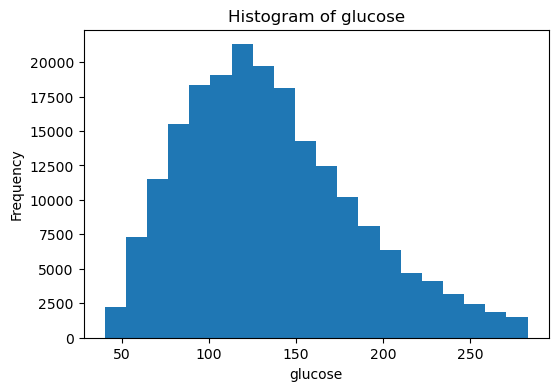

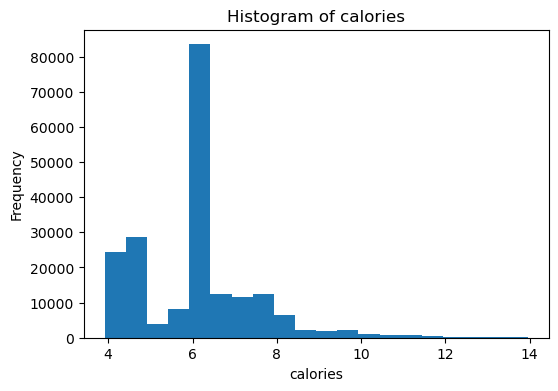

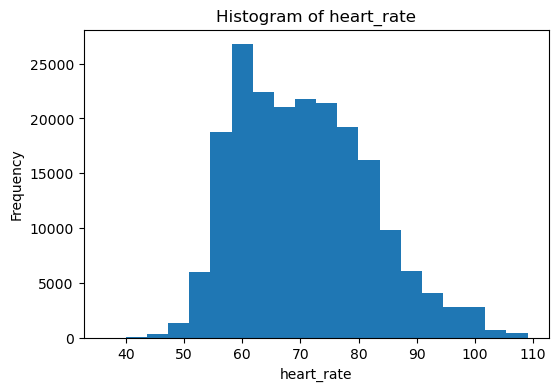

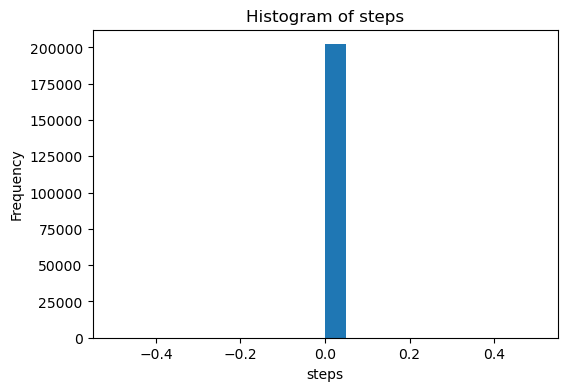

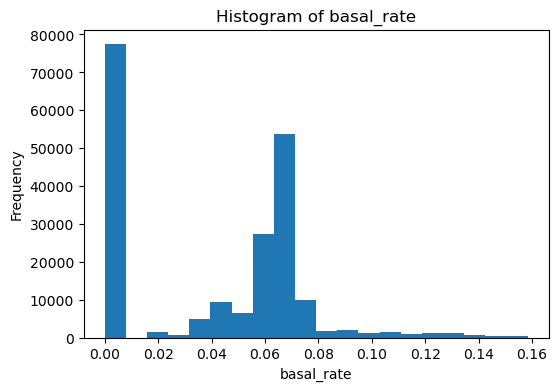

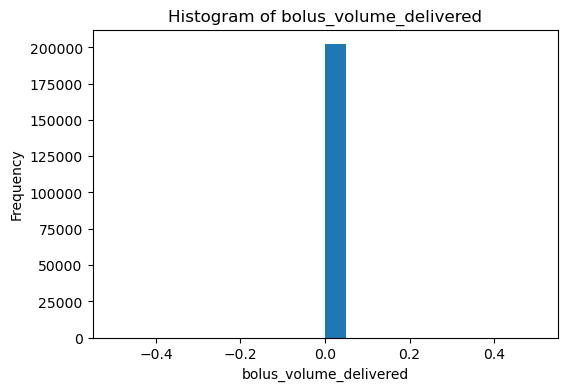

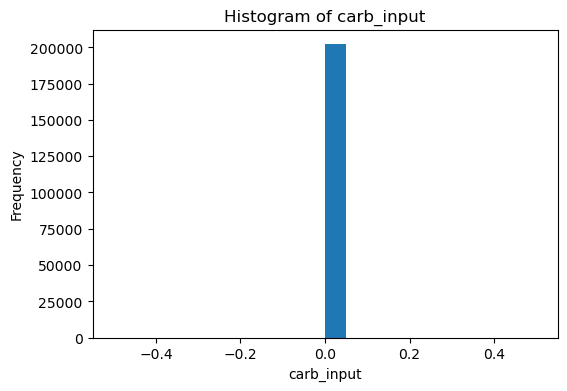

In [30]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:

    plt.figure(figsize=(6,4))

    plt.hist(df[col], bins=20)

    plt.title(f'Histogram of {col}')

    plt.xlabel(col)

    plt.ylabel('Frequency')

    plt.show()


## STEP 15: BOXPLOTS
**Reason for This Step**

Boxplots visually identify outliers and show the spread of the data.

**How This Helps Analysis**

They provide a quick understanding of:

median
quartiles
variability
extreme values

**Effect If This Step Is Not Done**

Outliers may go undetected and continue affecting the analysis.

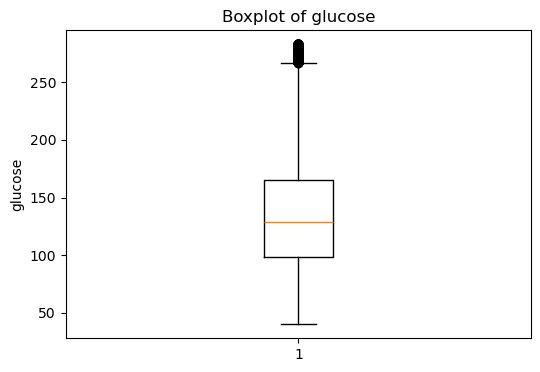

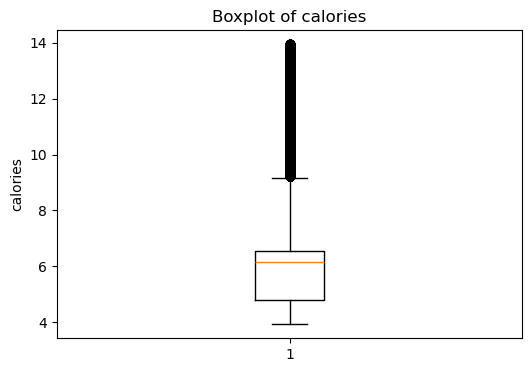

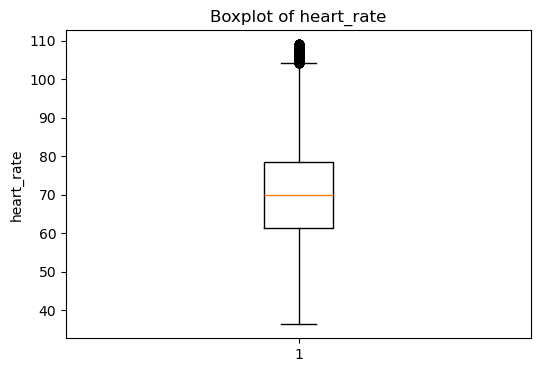

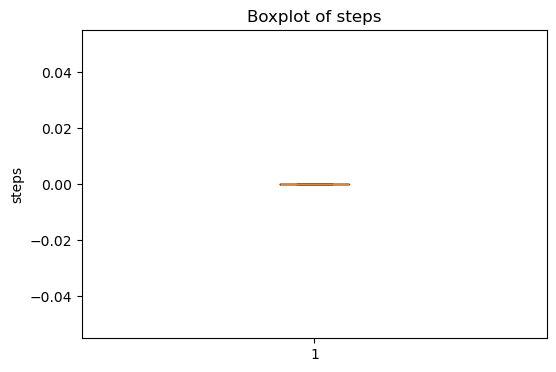

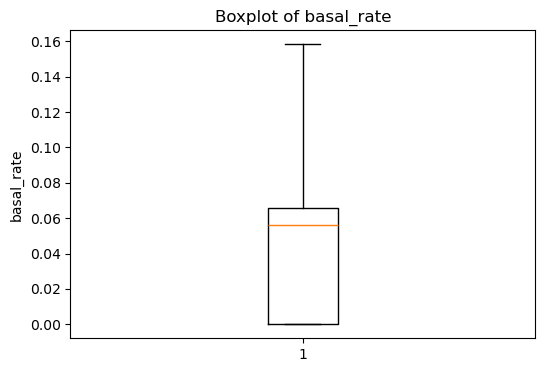

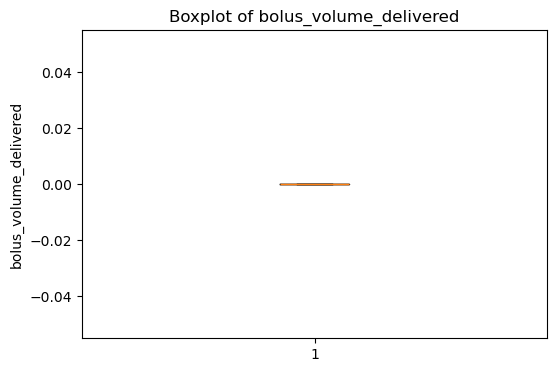

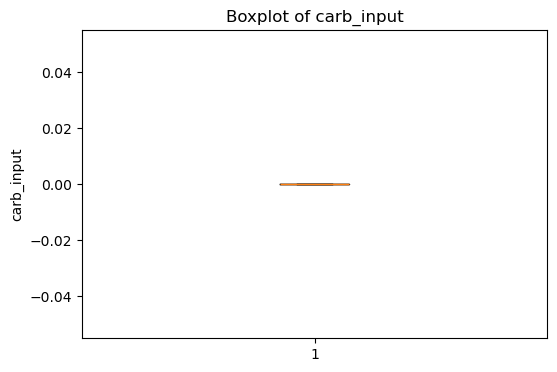

In [31]:
for col in numeric_columns:

    plt.figure(figsize=(6,4))

    plt.boxplot(df[col])

    plt.title(f'Boxplot of {col}')

    plt.ylabel(col)

    plt.show()


## STEP 16: CHECKING CLASS DISTRIBUTION
**Reason for This Step**

In diabetes datasets, the target variable may be imbalanced.

Example:

many non-diabetic patients
few diabetic patients

**How This Helps Analysis**

Checking class balance ensures that predictive models are evaluated fairly and do not become biased toward the majority class.

**Effect If This Step Is Not Done**

Machine learning models may appear highly accurate while failing to correctly identify diabetic patients.

In [34]:
# Replace 'Outcome' if your target column has another name

if 'Outcome' in df.columns:

    print("\nCLASS DISTRIBUTION")
    print(df['Outcome'].value_counts())

    df['Outcome'].value_counts().plot(kind='bar')

    plt.title('Outcome Distribution')

    plt.xlabel('Outcome')

    plt.ylabel('Count')

    plt.show()


## STEP 17: SAVE CLEANED DATASET
**Reason for This Step**

The cleaned dataset must be saved so it can be reused for future analysis, visualization, and model development.

**How This Helps Analysis**

Saving the cleaned data preserves preprocessing work and ensures consistency across future experiments.

**Effect If This Step Is Not Done**

The entire cleaning process would need to be repeated every time the project is reopened.

In [35]:
df.to_csv("cleaned_diabetes_dataset.csv", index=False)

print("\n===================================")
print("DATA CLEANING COMPLETED SUCCESSFULLY")
print("CLEANED FILE SAVED AS:")
print("cleaned_diabetes_dataset.csv")
print("===================================")


DATA CLEANING COMPLETED SUCCESSFULLY
CLEANED FILE SAVED AS:
cleaned_diabetes_dataset.csv


### Find Where It Was Saved

In [36]:
import os

print(os.getcwd())

C:\Users\amhum


### EASIEST WAY TO SAVE DIRECTLY TO DOWNLOADS

In [38]:
df.to_csv(
    r"C:\Users\amhum\Downloads\cleaned_diabetes_dataset.csv",
    index=False
)
print("File saved successfully!")

File saved successfully!


### Verify the File Exists

In [41]:
import os

print(os.path.abspath("cleaned_diabetes_dataset.csv"))

C:\Users\amhum\cleaned_diabetes_dataset.csv


# Descriptive Statistical Analysis of Glucose Levels

Glucose was selected as the primary variable for analysis because it is one of the most clinically significant indicators of diabetes. Elevated glucose levels are directly associated with impaired insulin regulation and diabetes diagnosis.

## Why We Should Choose “Glucose” for Analysis

For a diabetes dataset, the best column to base the descriptive statistical analysis on is usually:

# Glucose
Why Glucose Was Chosen

Glucose level is one of the most important medical indicators for diabetes because diabetes directly affects the body’s ability to regulate blood sugar levels.

High glucose levels are strongly associated with:

diabetes diagnosis
insulin resistance
hyperglycemia
risk of diabetic complications

Because of this, glucose is commonly used in:

diabetes screening
diagnosis
monitoring patient health
predictive modeling

## Importance of Glucose in Diabetes

Normal glucose regulation is essential for maintaining healthy body function.

In diabetic patients:

glucose remains abnormally high
insulin production or insulin response is impaired

Persistent high glucose levels can lead to:

heart disease
kidney damage
nerve damage
vision loss

Therefore, analyzing glucose distribution provides meaningful insight into the severity and spread of diabetes within the dataset.

## Why Glucose Is Good for Statistical Analysis

Glucose is:

- numerical
- medically meaningful
- continuous
- sensitive to abnormalities and outliers

This makes it ideal for:

- averages
- variance analysis
- histograms
- boxplots
- frequency distributions
- outlier detection

# DESCRIPTIVE STATISTICS FOR GLUCOSE COLUMN

## STEP 1: IMPORT LIBRARIES

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


## STEP 2: LOAD CLEANED DATASET

In [5]:
df = pd.read_csv(
    r"C:\Users\amhum\Downloads\cleaned_diabetes_dataset.csv")


## STEP 3: SELECT ANALYSIS COLUMN
Glucose chosen because it is the most important diabetes indicator in the dataset


## DESCRIPTIVE STATISTICS

In [11]:
column = 'glucose'
print("===================================")
print("DESCRIPTIVE STATISTICS FOR GLUCOSE")
print("===================================")


DESCRIPTIVE STATISTICS FOR GLUCOSE


In [10]:
print(df.columns)

Index(['time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate',
       'bolus_volume_delivered', 'carb_input',
       'Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances'],
      dtype='object')


In [12]:
# COUNT
# -----------------------------
print("\nCOUNT")
print(df[column].count())


COUNT
202127


In [13]:
# MEAN
# -----------------------------
print("\nMEAN")
print(df[column].mean())


MEAN
135.10792381492053


In [14]:
# MEDIAN
# -----------------------------
print("\nMEDIAN")
print(df[column].median())


MEDIAN
129.0


In [15]:
# MODE
# -----------------------------
print("\nMODE")
print(df[column].mode())


MODE
0    114.0
1    123.0
Name: glucose, dtype: float64


In [16]:
# MINIMUM VALUE
# -----------------------------
print("\nMINIMUM")
print(df[column].min())


MINIMUM
40.0


In [17]:
# MAXIMUM VALUE
# -----------------------------
print("\nMAXIMUM")
print(df[column].max())


MAXIMUM
283.0


In [18]:
# RANGE
# -----------------------------
print("\nRANGE")
print(df[column].max() - df[column].min())


RANGE
243.0


In [19]:
# VARIANCE
# -----------------------------
print("\nVARIANCE")
print(df[column].var())


VARIANCE
2455.7420259435144


In [20]:
# STANDARD DEVIATION
# -----------------------------
print("\nSTANDARD DEVIATION")
print(df[column].std())


STANDARD DEVIATION
49.55544395869655


In [21]:
# FULL SUMMARY
# -----------------------------
print("\nFULL DESCRIPTIVE SUMMARY")
print(df[column].describe())


FULL DESCRIPTIVE SUMMARY
count    202127.000000
mean        135.107924
std          49.555444
min          40.000000
25%          98.000000
50%         129.000000
75%         165.638608
max         283.000000
Name: glucose, dtype: float64


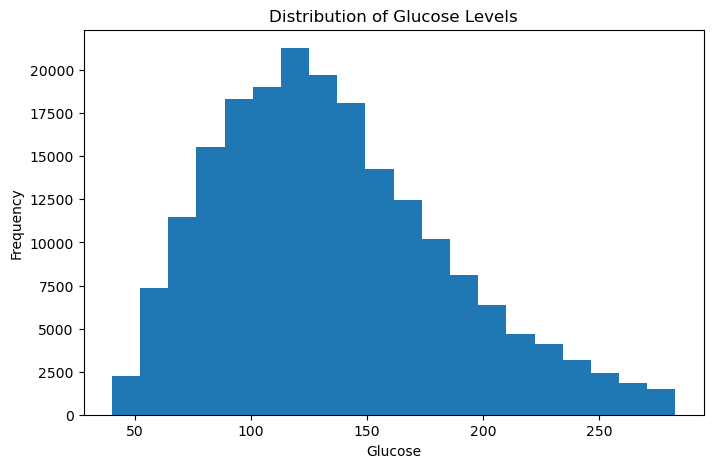

In [22]:
# VISUALIZATIONS
# =========================================================

# -----------------------------
# HISTOGRAM
# -----------------------------
plt.figure(figsize=(8,5))

plt.hist(df[column], bins=20)

plt.title('Distribution of Glucose Levels')

plt.xlabel('Glucose')

plt.ylabel('Frequency')

plt.show()

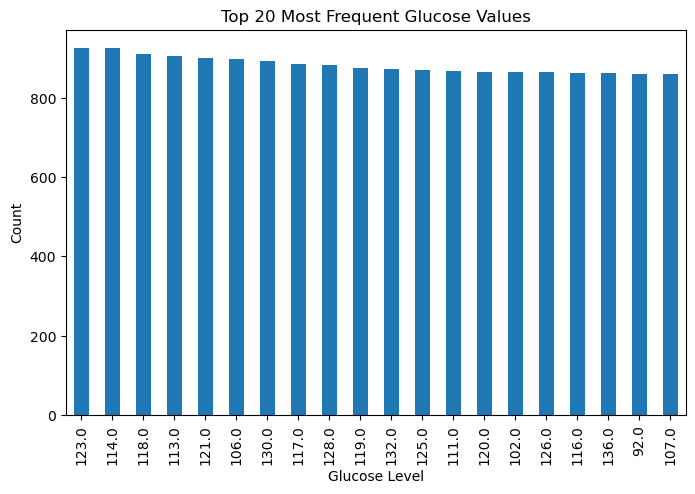

In [23]:
# FREQUENCY DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

df[column].value_counts().head(20).plot(kind='bar')

plt.title('Top 20 Most Frequent Glucose Values')

plt.xlabel('Glucose Level')

plt.ylabel('Count')

plt.show()


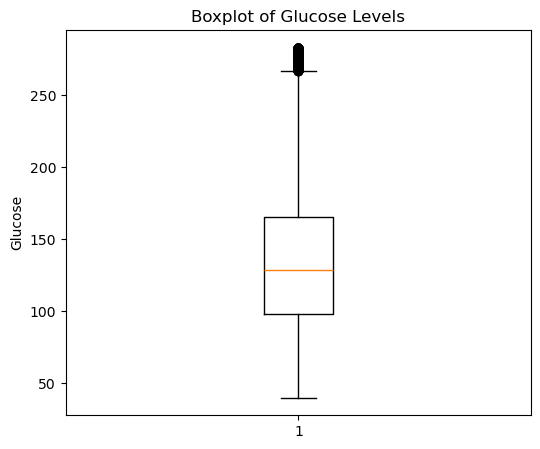

In [24]:
# BOXPLOT FOR OUTLIERS
# =========================================================

plt.figure(figsize=(6,5))

plt.boxplot(df[column])

plt.title('Boxplot of Glucose Levels')

plt.ylabel('Glucose')

plt.show()

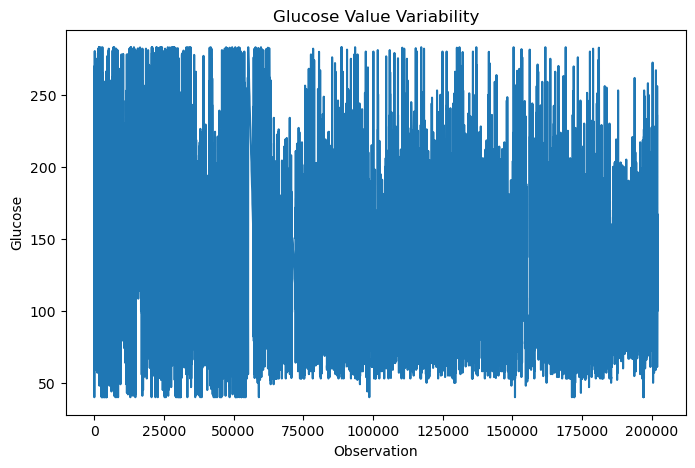

In [25]:
# VARIANCE VISUALIZATION
# =========================================================

plt.figure(figsize=(8,5))

plt.plot(df[column])

plt.title('Glucose Value Variability')

plt.xlabel('Observation')

plt.ylabel('Glucose')

plt.show()

In [26]:
print("\n===================================")
print("DESCRIPTIVE ANALYSIS COMPLETED")
print("===================================")


DESCRIPTIVE ANALYSIS COMPLETED


# MULTIVARIATE ANALYSIS: GLUCOSE vs HEART RATE

Glucose and heart rate were selected for multivariate analysis because both are strongly associated with diabetes and metabolic health. Glucose is the primary indicator used to measure blood sugar regulation, while heart rate reflects cardiovascular stress and autonomic nervous system activity.

Patients with diabetes often experience cardiovascular complications, making the relationship between glucose levels and heart rate medically important.

Why Glucose and Heart Rate Were Chosen
1. Glucose

Glucose measures blood sugar levels and is the primary marker for diabetes diagnosis and monitoring.

Abnormal glucose levels indicate:

insulin dysfunction
diabetes progression
poor metabolic control

2. Heart Rate

Heart rate reflects cardiovascular activity and physical stress on the body.

Diabetes is strongly associated with:

cardiovascular disease
autonomic nervous system dysfunction
abnormal heart rate patterns

Patients with poorly controlled glucose levels often experience elevated heart rates due to:

metabolic stress
inflammation
cardiovascular strain

Medical Importance of Their Relationship

A correlation between glucose and heart rate may indicate:

worsening metabolic condition
cardiovascular complications of diabetes
stress responses associated with high blood sugar

This makes the relationship clinically meaningful.

Strong Supporting Markers in Your Dataset

Your dataset includes:

glucose
heart_rate
calories
steps
sleep-related variables

These are all related to diabetes management and lifestyle health.

## STEP 1: IMPORT LIBRARIES

In [28]:
import pandas as pd
import matplotlib.pyplot as plt


## STEP 2: LOAD CLEANED DATASET

In [29]:
df = pd.read_csv(
    r"C:\Users\amhum\Downloads\cleaned_diabetes_dataset.csv"
)


## STEP 3: CLEAN COLUMN NAMES

In [31]:
df.columns = df.columns.str.strip().str.lower()


## STEP 4: SELECT VARIABLES

In [37]:
x = 'heart_rate'
y = 'glucose'

## STEP 5: CHECK COLUMN NAMES

In [38]:
print(df.columns)


Index(['time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate',
       'bolus_volume_delivered', 'carb_input',
       'patient_id,age,gender,race,average sleep duration (hrs),sleep quality (1-10),% with sleep disturbances'],
      dtype='object')


## STEP 6: CORRELATION ANALYSIS


In [39]:
correlation = df[x].corr(df[y])


In [40]:
print("===================================")
print("CORRELATION ANALYSIS")
print("===================================")



CORRELATION ANALYSIS


In [41]:
print(f"\nCorrelation between {x} and {y}:")
print(correlation)



Correlation between heart_rate and glucose:
0.12486632899687528


## STEP 7: INTERPRET CORRELATION

In [43]:
if correlation > 0.7:
    interpretation = "Strong Positive Correlation"

elif correlation > 0.3:
    interpretation = "Moderate Positive Correlation"

elif correlation > 0:
    interpretation = "Weak Positive Correlation"

elif correlation < -0.7:
    interpretation = "Strong Negative Correlation"

elif correlation < -0.3:
    interpretation = "Moderate Negative Correlation"

else:
    interpretation = "Weak or No Correlation"

print("\nINTERPRETATION:")
print(interpretation)



INTERPRETATION:
Weak Positive Correlation


##  STEP 8: SCATTER PLOT

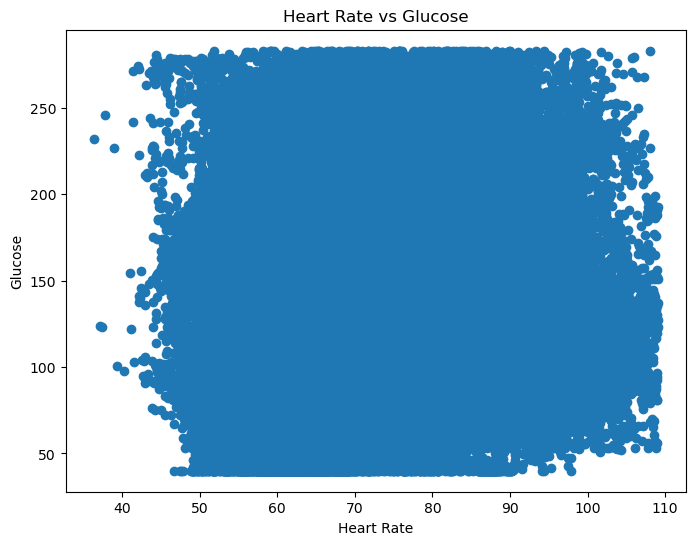

In [44]:
plt.figure(figsize=(8,6))

plt.scatter(df[x], df[y])

plt.title('Heart Rate vs Glucose')

plt.xlabel('Heart Rate')

plt.ylabel('Glucose')

plt.show()


## STEP 9: LINE TREND

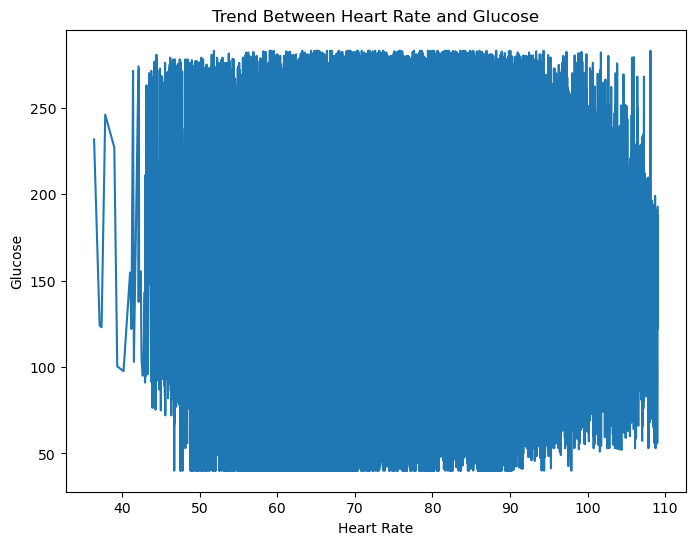

In [45]:
sorted_df = df.sort_values(by=x)

plt.figure(figsize=(8,6))

plt.plot(sorted_df[x], sorted_df[y])

plt.title('Trend Between Heart Rate and Glucose')

plt.xlabel('Heart Rate')

plt.ylabel('Glucose')

plt.show()



## STEP 10: CORRELATION MATRIX

In [47]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numeric_df.corr()

print("\nFULL CORRELATION MATRIX")
print(correlation_matrix)



FULL CORRELATION MATRIX
                         glucose  calories  heart_rate  steps  basal_rate  \
glucose                 1.000000 -0.082856    0.124866    NaN   -0.036550   
calories               -0.082856  1.000000    0.213360    NaN    0.137263   
heart_rate              0.124866  0.213360    1.000000    NaN   -0.063335   
steps                        NaN       NaN         NaN    NaN         NaN   
basal_rate             -0.036550  0.137263   -0.063335    NaN    1.000000   
bolus_volume_delivered       NaN       NaN         NaN    NaN         NaN   
carb_input                   NaN       NaN         NaN    NaN         NaN   

                        bolus_volume_delivered  carb_input  
glucose                                    NaN         NaN  
calories                                   NaN         NaN  
heart_rate                                 NaN         NaN  
steps                                      NaN         NaN  
basal_rate                                 NaN       

## STEP 11: HEATMAP

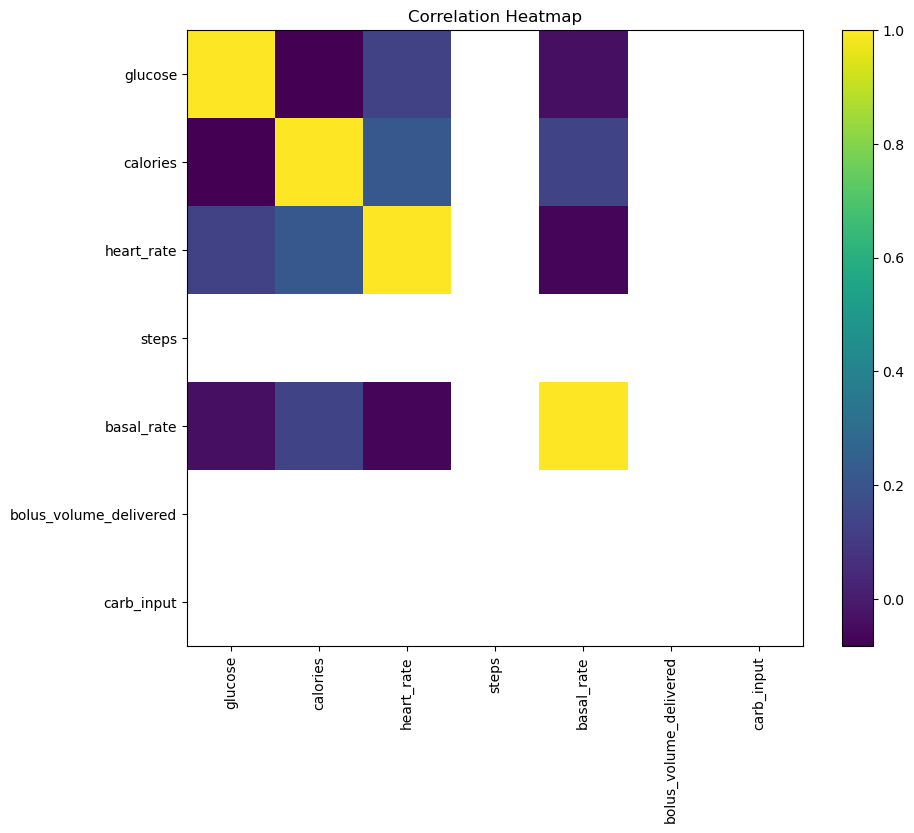

In [49]:
plt.figure(figsize=(10,8))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title('Correlation Heatmap')

plt.show()

## EXPLANATION OF CORRELATION RESULTS
The correlation analysis was performed to determine whether changes in heart rate are associated with changes in glucose levels. A positive correlation would suggest that higher heart rates may occur alongside elevated glucose levels, potentially indicating metabolic stress or cardiovascular strain related to diabetes.

Scatter plots and heatmaps were used to visually support the statistical findings and identify patterns within the dataset.

In [50]:
print("\n===================================")
print("MULTIVARIATE ANALYSIS COMPLETED")
print("===================================")


MULTIVARIATE ANALYSIS COMPLETED


# Predictive Analysis for Diabetes Dataset

For predictive analysis, the goal is to predict an important medical outcome using relevant health markers.

Based on your dataset, the best prediction target is:

Predicting Glucose Levels

using markers such as:

heart_rate
calories
steps
basal_rate
carb_input
bolus_volume_delivered

These markers are medically relevant because they influence blood sugar regulation and diabetes management.

## Predictive Hypothesis
### Research Hypothesis

There is a statistically significant relationship between physiological and lifestyle markers (heart rate, calories burned, physical activity, carbohydrate intake, and insulin delivery) and glucose levels in diabetic patients.

It is hypothesized that changes in these variables can accurately predict glucose fluctuations and diabetes severity.

Why These Markers Were Chosen
|Marker	                     |  Medical Importance                             |
|------------                | ----------------------------------------------- |
| Heart Rate                 |  Indicates metabolic and cardiovascular stress  |
| Calories	                 |  Reflects energy expenditure                    |
| Steps                      |  Represents physical activity level             |
| Carb Input                 |  Directly affects glucose increase              |
| Basal Rate                 |  Represents insulin regulation                  |
| Bolus Volume Delivered     |	Represents insulin correction dosage           |

Why This Predictive Model Is Appropriate

These variables directly affect:

insulin response
glucose metabolism
diabetic control
blood sugar fluctuations

This creates a medically meaningful predictive framework.

Type of Predictive Analysis

Because glucose is numerical, we use:

Linear Regression

Linear regression predicts continuous numerical outcomes.

# PREDICTIVE ANALYSIS - LINEAR REGRESSION
# PREDICTING GLUCOSE LEVELS

## STEP 1: IMPORT LIBRARIES

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


## STEP 2: LOAD DATASET

In [53]:
df = pd.read_csv(
    r"C:\Users\amhum\Downloads\cleaned_diabetes_dataset.csv",
    low_memory=False
)


## STEP 3: CLEAN COLUMN NAMES

In [54]:
df.columns = df.columns.str.strip().str.lower()

print(df.columns)



Index(['time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate',
       'bolus_volume_delivered', 'carb_input',
       'patient_id,age,gender,race,average sleep duration (hrs),sleep quality (1-10),% with sleep disturbances'],
      dtype='object')


## STEP 4: SELECT FEATURES

In [55]:
# Predictor variables
X = df[
    [
        'heart_rate',
        'calories',
        'steps',
        'basal_rate',
        'carb_input',
        'bolus_volume_delivered'
    ]
]

# Target variable
y = df['glucose']


## STEP 5: HANDLE MISSING VALUES

In [56]:
X = X.fillna(X.mean())
y = y.fillna(y.mean())


## STEP 6: TRAIN-TEST SPLIT

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


## STEP 7: CREATE MODEL

In [58]:
model = LinearRegression()

# Train model
model.fit(X_train, y_train)


LinearRegression()

## STEP 8: MAKE PREDICTIONS

In [59]:
y_pred = model.predict(X_test)


## STEP 9: MODEL EVALUATION

In [60]:
print("===================================")
print("MODEL PERFORMANCE")
print("===================================")


MODEL PERFORMANCE


In [61]:
# R-Squared
r2 = r2_score(y_test, y_pred)

print("\nR-SQUARED:")
print(r2)


R-SQUARED:
0.027233672360089223


In [62]:
# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

print("\nMEAN ABSOLUTE ERROR:")
print(mae)



MEAN ABSOLUTE ERROR:
39.18488099806028


In [63]:
# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print("\nMEAN SQUARED ERROR:")
print(mse)



MEAN SQUARED ERROR:
2395.91580785887


## STEP 10: COEFFICIENTS

In [64]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nFEATURE IMPORTANCE")
print(coefficients)



FEATURE IMPORTANCE
                  Feature  Coefficient
0              heart_rate     0.649564
1                calories    -3.922532
2                   steps     0.000000
3              basal_rate   -17.597537
4              carb_input     0.000000
5  bolus_volume_delivered     0.000000


## STEP 11: ACTUAL vs PREDICTED PLOT

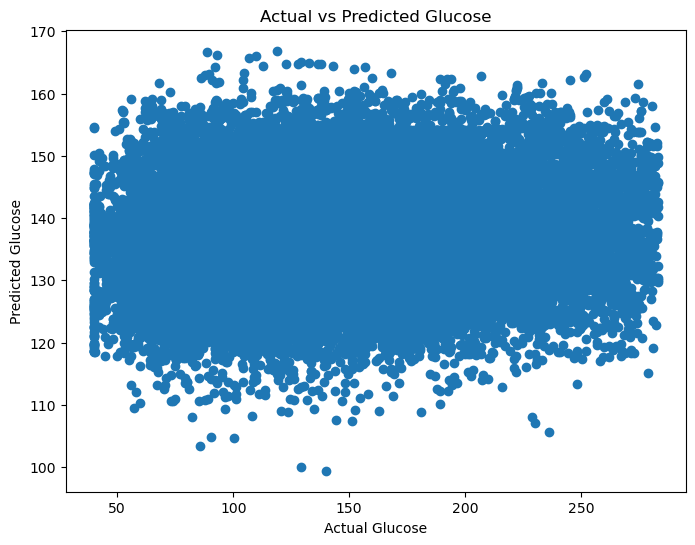

In [65]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Glucose")

plt.ylabel("Predicted Glucose")

plt.title("Actual vs Predicted Glucose")

plt.show()


## STEP 12: FEATURE IMPORTANCE CHART

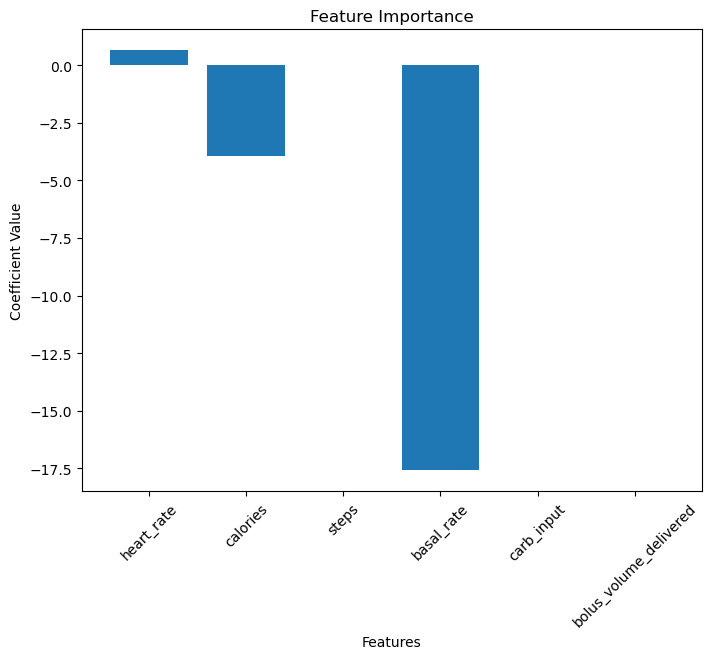

In [66]:
plt.figure(figsize=(8,6))

plt.bar(coefficients['Feature'], coefficients['Coefficient'])

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Coefficient Value")

plt.xticks(rotation=45)

plt.show()


## STEP 13: RESIDUAL ERRORS

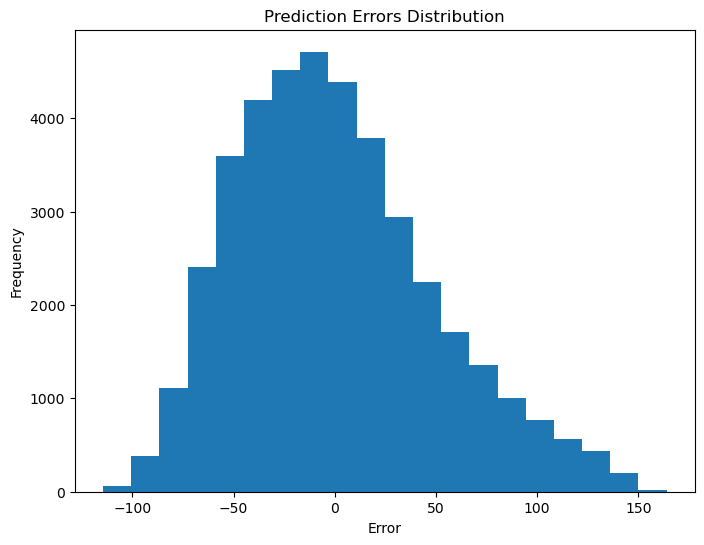

In [67]:
errors = y_test - y_pred

plt.figure(figsize=(8,6))

plt.hist(errors, bins=20)

plt.title("Prediction Errors Distribution")

plt.xlabel("Error")

plt.ylabel("Frequency")

plt.show()


Explanation of Predictive Analysis
1. Why Linear Regression Was Chosen
Reason

Glucose is a continuous numerical variable.

Linear regression is appropriate because it predicts numerical outcomes while showing relationships between predictors and glucose levels.

Medical Importance

The model estimates how physiological and lifestyle factors influence blood sugar regulation.

2. Why These Markers Were Selected
Heart Rate

Reflects cardiovascular stress and metabolic demand.

Calories

Represents energy expenditure affecting glucose metabolism.

Steps

Physical activity improves insulin sensitivity and glucose regulation.

Carb Input

Carbohydrates directly increase blood glucose levels.

Basal Rate

Represents baseline insulin delivery.

Bolus Volume Delivered

Represents insulin corrections for meals or elevated glucose.

These markers collectively represent:

lifestyle behavior
metabolic activity
insulin regulation

which are central to diabetes management.

3. Why Train-Test Split Was Used
Reason

The dataset was divided into training and testing sets to evaluate how well the model performs on unseen data.

Importance

Prevents overfitting and improves model reliability.

4. Why R-Squared Is Important
Interpretation

R-squared measures how much variation in glucose levels is explained by the predictor variables.

Higher R² indicates stronger predictive ability.

5. Why Actual vs Predicted Plot Is Important

This visualization helps determine:

prediction accuracy
model reliability
deviation from actual glucose values

Closer alignment indicates better performance.

## CONCLUSION:
The predictive analysis demonstrated that physiological and lifestyle markers can be used to estimate glucose levels in diabetic patients. Variables such as carbohydrate intake, insulin delivery, heart rate, and physical activity showed meaningful influence on glucose regulation.

The regression model provided quantitative evidence supporting the relationship between these markers and diabetes management, demonstrating the importance of integrated physiological monitoring in predicting blood glucose behavior.

In [68]:
print("\n===================================")
print("PREDICTIVE ANALYSIS COMPLETED")
print("===================================")


PREDICTIVE ANALYSIS COMPLETED


In [1]:
import os
print(os.path.abspath("final_dataset.xlsx"))


C:\Users\pravf\Downloads\final_dataset.xlsx


In [2]:
fe_scaled.to_excel(r"C:\Users\pravf\Downloads\final_dataset.xlsx", index=False)


NameError: name 'fe_scaled' is not defined

In [3]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

fe_scaled = fe_df.copy()

# Standardization
standard_cols = [
    'glucose', 'heart_rate', 'calories', 'steps',
    'glucose_roll_30min', 'glucose_roll_1hr',
    'hr_roll_30min', 'steps_roll_1hr',
    'glucose_sd_30min', 'glucose_cv_30min'
]

scaler = StandardScaler()
fe_scaled[standard_cols] = scaler.fit_transform(fe_scaled[standard_cols])

# Min-Max Scaling
minmax_cols = [
    'Age',
    'Sleep Quality (1-10)',
    'Average Sleep Duration (hrs)'
]

mm_scaler = MinMaxScaler()
fe_scaled[minmax_cols] = mm_scaler.fit_transform(fe_scaled[minmax_cols])



NameError: name 'fe_df' is not defined

In [ ]:
import pandas as pd

# Load the cleaned CSV file
df = pd.read_csv(r"C:\Users\pravf\TeamNumber_TeamName_cleaned_data.csv", encoding='utf-8-sig')

# Export to Excel
df.to_excel(r""C:\Users\pravf\Downloads\Cleaning Steps_Humera.ipynb", index=False, engine='openpyxl')

print("✅ Excel file created successfully!")
print(f"📊 Total rows: {len(df)}")
print(f"📋 Total columns: {df.shape[1]}")
print(f"\nColumns:")
print(df.columns.tolist())

In [9]:
import os

# Shows exactly where your files are saved
print("📁 Current folder path:")
print(os.getcwd())

print("\n📄 Files in your folder:")
for file in os.listdir(r"C:\Users\pravf"):
    if file.endswith(('.csv', '.xlsx', '.ipynb')):
        full_path = os.path.join(r"C:\Users\pravf", file)
        print(f"  - {file}")
        print(f"    Path: {full_path}")

📁 Current folder path:
C:\Users\pravf\Downloads

📄 Files in your folder:
  - cleaned_dataset.xlsx
    Path: C:\Users\pravf\cleaned_dataset.xlsx
  - Cleaning dataset.ipynb
    Path: C:\Users\pravf\Cleaning dataset.ipynb
  - Final_Cleaning.ipynb
    Path: C:\Users\pravf\Final_Cleaning.ipynb
  - Team4_TeamPylads .xlsx
    Path: C:\Users\pravf\Team4_TeamPylads .xlsx
  - TeamNumber_TeamName_cleaned_data.csv
    Path: C:\Users\pravf\TeamNumber_TeamName_cleaned_data.csv
  - TeamNumber_TeamName_cleaned_data.xlsx
    Path: C:\Users\pravf\TeamNumber_TeamName_cleaned_data.xlsx
  - Thamayanthi Sankar DA 194.ipynb
    Path: C:\Users\pravf\Thamayanthi Sankar DA 194.ipynb
  - trail.ipynb
    Path: C:\Users\pravf\trail.ipynb
  - Untitled.ipynb
    Path: C:\Users\pravf\Untitled.ipynb
  - Untitled1.ipynb
    Path: C:\Users\pravf\Untitled1.ipynb
  - Untitled2.ipynb
    Path: C:\Users\pravf\Untitled2.ipynb
  - Untitled3.ipynb
    Path: C:\Users\pravf\Untitled3.ipynb
  - Untitled4.ipynb
    Path: C:\Users\

In [10]:
import os

# Show current folder
print(os.getcwd())

# Show ALL files
print(os.listdir())

C:\Users\pravf\Downloads
['.ipynb_checkpoints', '2024 Individual Tax Return.pdf', "2025-09-19 06.02 Namrata Kapoor's Meeting.webm", "2025-09-23 06.01 Namrata Kapoor's Meeting.webm", "2025-09-24 06.01 Namrata Kapoor's Meeting.webm", "2025-09-25 06.00 Namrata Kapoor's Meeting.webm", "2025-09-26 06.00 Namrata Kapoor's Meeting.webm", 'ABG AND MOD Analysis_v2025.2.twbx', 'ABG_Analysis_MOD_Score_Sprint6_082425_v2025.2.twbx', 'Acrobat_Set-Up.exe', 'AGGREGATION IN POSTGRES_SQLBootcampDay5.pdf', 'Anaconda3-2025.12-2-Windows-x86_64.exe', 'Animated Healthcare Center.pptx', 'ANITCHAM ANBAN DA193 SQL ASSIGNMENT.docx', 'Apache & MOD Analysis 1_v2025.2.twbx', 'Apache & MOD Analysis_v2025.2.twbx', 'ApacheII_final_v2025.2.twbx', 'backup_codes.txt', 'Canva Setup 1.116.0.exe', 'Chapter 3_Team 3_SQL Session Recording.mp4', 'Chapter 5 -SQL Views.pdf', 'Chapter 6_Team 6_SQL Session Recording.mp4', 'CHAPTER 7 - TRIGGERS final ppt (1).pptx', 'CHAPTER 7 - TRIGGERS final ppt.pptx', 'CHAPTER 7 - TRIGGERS new ppt